# An example workflow for the orbyts-black-hole-shadows package

This notebook aims to clarify the workflow when generating a simulated black 
hole shadow image with the orbyts-black-hole-shadows package. (v0.0.2)

In [8]:
# We need to import three classes from the package: Metric, Box, and Source
from orbyts_black_hole_shadows.utils import Metric
from orbyts_black_hole_shadows.sources import Source, Box

## Specifying a modified black hole spacetime

The modified black hole metric can be specified using the **`Metric()`** class.
Currently, only non-spinning black holes are supported with metrics of the form

$ds^2 = -A(r) dt^2 + \frac{dr^2}{B(r)} + r^2 d\Omega^2$,

where $d\Omega^2$ is the angular line element. To specify the metric (and in the
entire package) all radii should be given in units of the Schwarzschild radius $R_s$.

In [9]:
# For this example, we consider a GR Schwarzschild metric defined as

def A(r):
    return 1-1/r
def B(r):
    return 1-1/r
def dAdr(r):
    return 1/r**2
def dBdr(r):
    return 1/r**2

schw_metric = Metric(A,B,dAdr,dBdr)

## Defining a source

To define the photon source we use the **`Source()`** class. We first need 
formulate a condition for a certain point to be inside the source, which is 
passed to the **`Source()`**  class as a function of a coordinate returning a
boolean. Currently support for Cartesian, Spherical polar and Cylyndrical polar
coordinate systems is available. Below we define several sources as examples.
Note that in all cases the observer is looking down from the positive $z$
direction, while the black hole is centered on the origin.

In [10]:
# Sphere of radius 5
sphere = Source(condition=lambda x: x[0] < 5, coordinates="Spherical")

# Disc of inner radius 2 and outer radius 5 with thickness 1
disc = Source(condition=lambda x: -0.5 < x[2] < 0.5 and 2 < x[0] < 5, coordinates="Cylindrical")

# Add a few more...

## Generating an image

Finally, we use the **`Box()`** class to define the box in which our black hole 
and source live, and use it to do the required calculations for simulating a
shadow. Starting with the example of the spherical source at low resolution for quick runs.


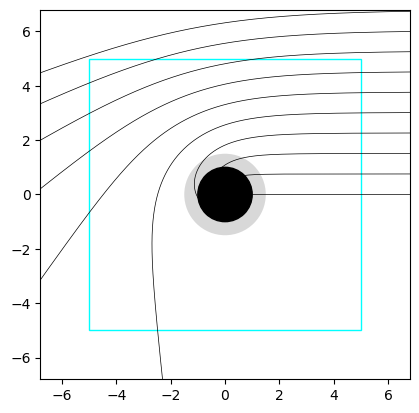

In [11]:
# Initialising the box with a certain size. Make sure the source you have 
# fits inside this box.
box_sphere = Box(box_size=10, box_points=50)

# We then calculate the photon rays for different impact parameters.
box_sphere.calculate_photon_rays(n_b=10, metric=schw_metric, D=1000, b_max=6.8)
# And plotting these calculated photon rays
box_sphere.plot_box_orbits()

When choosing values for box_points and n_b (and later n_alpha) ensure that 
box_points is larger than either of these two values (ideally by an order 
of magnitude) to prevent discretisation issues.

Additionally, the blue contour indicates the size of the box. The value of b_max
should be taken slightly larger than box_size / 2 to ensure that the entire box 
is covered by photon rays. This can be done by trial and error with a low n_b
and plotting the rays as above.

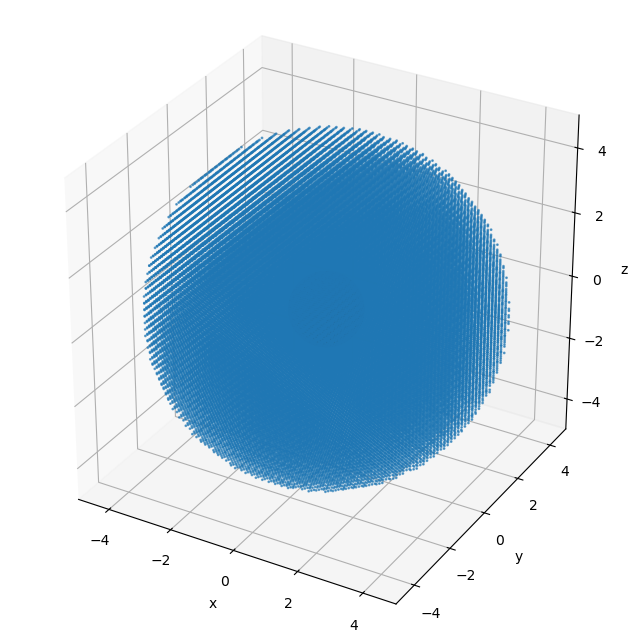

In [12]:
# We then add our spherical source to the box
box_sphere.add_source(sphere)
# And we can plot it to check the orientation
box_sphere.plot_source()

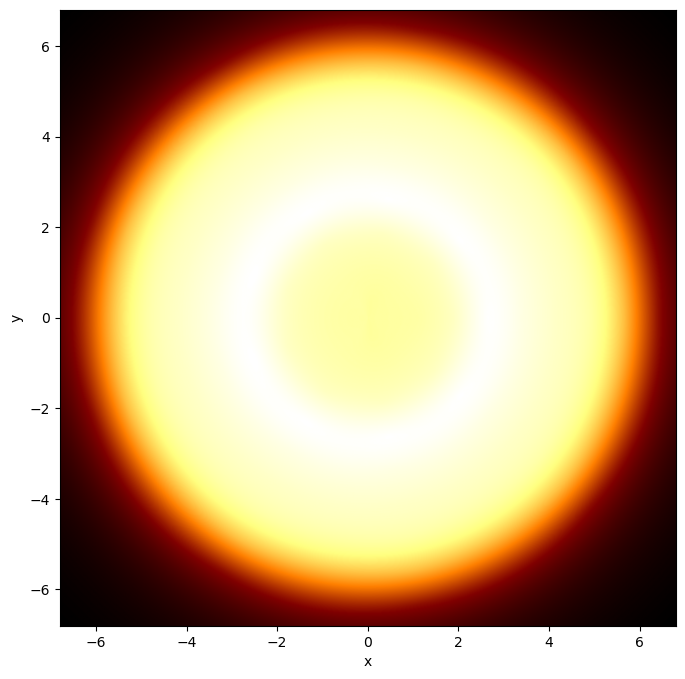

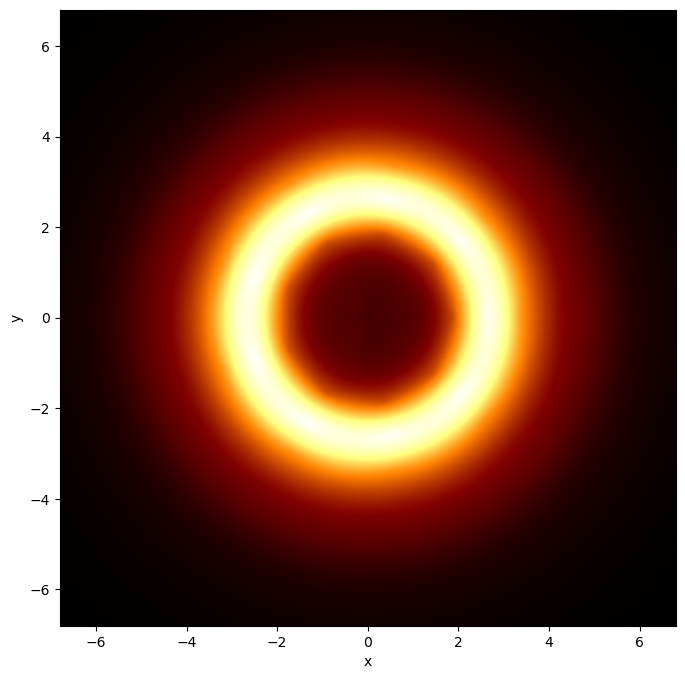

In [13]:
# We can finally calculate the pixel brightness and plot the resulting image
box_sphere.calculate_pixel_brightness(n_alpha=10)
box_sphere.plot_image(smoothing=1)
box_sphere.plot_image(smoothing=1, log=False)

The standard log=True option can make fainter features more clearly visible, but
it can also wash out brighter features as shown above. Note that even with this 
very low resolution, the photon ring and black hole shadow are clearly visible.